1.  Imports y configuración

In [8]:
import os
import json
import cv2
import numpy as np
from glob import glob
from pathlib import Path
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.patches as patches

RAW_IMG_DIR  = Path("../../data/raw/")
LABELS_DIR   = Path("../../data/processed/etiquetas/")
DATASET_DIR  = Path("../../data/processed/dataset/")
CROPS_DIR    = DATASET_DIR / "crops"
MANIFEST_PATH = DATASET_DIR / "manifest.json"

CROPS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_HEIGHT   = 64
MIN_WIDTH       = 32
MAX_WIDTH       = 1024
PADDING_PCT     = 0.15
BINARIZE        = True

imgs  = sorted(RAW_IMG_DIR.glob("*"))
jsons = sorted(LABELS_DIR.glob("*.json"))
print(f"Imágenes encontradas : {len(imgs)}")
print(f"JSONs encontrados    : {len(jsons)}")

Imágenes encontradas : 15
JSONs encontrados    : 15


2. Utilidades de geometría y recorte

In [9]:
def bbox_to_pixels(coord, img_w, img_h, padding=PADDING_PCT):
    """
    Convierte coordenadas porcentuales de Label Studio (x,y = esquina superior izquierda)
    a píxeles absolutos con padding opcional.
    Devuelve (x1, y1, x2, y2) clipeado al tamaño de la imagen.
    """
    x1_pct = coord["x"] / 100
    y1_pct = coord["y"] / 100
    w_pct  = coord["ancho"] / 100
    h_pct  = coord["alto"]  / 100

    # Convertir a píxeles
    x1 = x1_pct * img_w
    y1 = y1_pct * img_h
    x2 = x1 + w_pct * img_w
    y2 = y1 + h_pct * img_h

    # Padding en píxeles
    pad_x = (x2 - x1) * padding
    pad_y = (y2 - y1) * padding

    x1 = int(max(0,     x1 - pad_x))
    y1 = int(max(0,     y1 - pad_y))
    x2 = int(min(img_w, x2 + pad_x))
    y2 = int(min(img_h, y2 + pad_y))

    return x1, y1, x2, y2


def deskew_crop(crop_gray):
    """
    Corrige pequeñas inclinaciones en el recorte usando momentos de imagen.
    Solo aplica si el ángulo detectado es < 10°.
    """
    coords = np.column_stack(np.where(crop_gray < 200))
    if coords.shape[0] < 10:
        return crop_gray
    angle = cv2.minAreaRect(coords.astype(np.float32))[-1]
    if angle < -45:
        angle = 90 + angle
    if abs(angle) < 10:
        (h, w) = crop_gray.shape
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        crop_gray = cv2.warpAffine(crop_gray, M, (w, h),
                                   flags=cv2.INTER_CUBIC,
                                   borderMode=cv2.BORDER_REPLICATE)
    return crop_gray


def preprocess_crop(crop_bgr, target_h=TARGET_HEIGHT,
                    max_w=MAX_WIDTH, binarize=BINARIZE):
    """
    Pipeline completo sobre un recorte BGR:
      1. Escala de grises
      2. Deskew
      3. Binarización adaptativa o normalización
      4. Resize a target_h manteniendo aspecto
      5. Padding a max_w si es necesario
    Devuelve imagen (H, W) uint8.
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = deskew_crop(gray)

    if binarize:
        # Otsu sobre imagen suavizada
        blur  = cv2.GaussianBlur(gray, (3, 3), 0)
        _, out = cv2.threshold(blur, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        out = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

    # Resize conservando aspecto
    h, w = out.shape
    ratio   = target_h / h
    new_w   = max(MIN_WIDTH, min(int(w * ratio), max_w))
    resized = cv2.resize(out, (new_w, target_h), interpolation=cv2.INTER_AREA)

    if resized.shape[1] < max_w:
        pad = np.full((target_h, max_w - resized.shape[1]), 255, dtype=np.uint8)
        resized = np.hstack([resized, pad])

    return resized

3. Procesamiento principal (genera crops + manifest)

In [10]:
def bbox_to_pixels(ann, img_w, img_h, padding=PADDING_PCT):
    """
    Nuevo formato Label Studio:
    x, y = esquina superior izquierda (%)
    width, height = tamaño (%)
    """
    x1 = ann["x"]      / 100 * img_w
    y1 = ann["y"]      / 100 * img_h
    x2 = x1 + ann["width"]  / 100 * img_w
    y2 = y1 + ann["height"] / 100 * img_h

    pad_x = (x2 - x1) * padding
    pad_y = (y2 - y1) * padding

    x1 = int(max(0,     x1 - pad_x))
    y1 = int(max(0,     y1 - pad_y))
    x2 = int(min(img_w, x2 + pad_x))
    y2 = int(min(img_h, y2 + pad_y))

    return x1, y1, x2, y2

4. Verificación visual (muestreo aleatorio)

In [11]:
for json_path in jsons:
    with open(json_path, encoding="utf-8") as f:
        data = json.load(f)

    img_path = RAW_IMG_DIR / data["image"]   
    if not img_path.exists():
        print(f"[WARN] Imagen no encontrada: {img_path}")
        continue

    img_bgr = cv2.imread(str(img_path))
    img_h, img_w = img_bgr.shape[:2]

    for i, ann in enumerate(data["label"]):   
        etiqueta = ann["rectanglelabels"][0]       
        label    = ""                      

        x1, y1, x2, y2 = bbox_to_pixels(ann, img_w, img_h)

        if (x2 - x1) < MIN_WIDTH or (y2 - y1) < 10:
            print(f"[SKIP] bbox pequeño en {json_path.name} anotación {i}")
            continue

        crop_bgr  = img_bgr[y1:y2, x1:x2]
        crop_proc = preprocess_crop(crop_bgr)

        filename = f"{data['id']}_{etiqueta}_{i:03d}.png" 
        out_path = CROPS_DIR / filename
        cv2.imwrite(str(out_path), crop_proc)

        manifest.append({
            "img_path"   : str(out_path.relative_to(DATASET_DIR)),
            "label"      : label,       # vacío por ahora
            "etiqueta"   : etiqueta,
            "source_img" : data["image"],
            "bbox"       : [x1, y1, x2, y2]
        })

5. Estadísticas del dataset

=== Distribución por etiqueta ===
etiqueta
dni_contratante    24
n_contrato         20
monto              19
contratante        18
tel_contratante    18
fallecido          18
forma_pago         18
direccion          17
ataud              17
carroza            17
cargadores         17
capilla            16
fecha              15
carroza_flores     14
velatorio          13
vehiculos          12

Total muestras : 273
Labels únicos  : 1
Largo promedio de texto : 0.0 chars


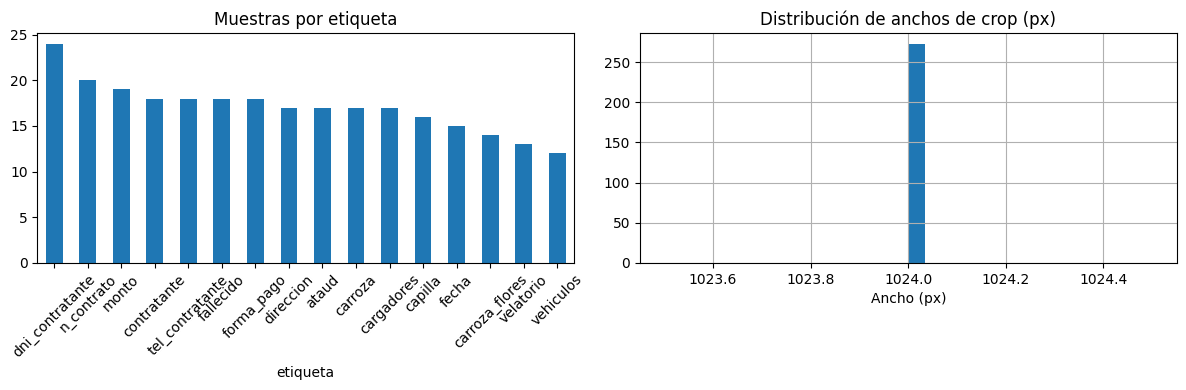

In [12]:
import pandas as pd

df = pd.DataFrame(manifest)

print("=== Distribución por etiqueta ===")
print(df["etiqueta"].value_counts().to_string())
print(f"\nTotal muestras : {len(df)}")
print(f"Labels únicos  : {df['label'].nunique()}")
print(f"Largo promedio de texto : {df['label'].str.len().mean():.1f} chars")

widths = []
for entry in manifest:
    img = cv2.imread(str(DATASET_DIR / entry["img_path"]), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        widths.append(img.shape[1])

df["crop_width"] = widths

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["etiqueta"].value_counts().plot(kind="bar", ax=axes[0], title="Muestras por etiqueta")
axes[0].tick_params(axis='x', rotation=45)
df["crop_width"].hist(bins=30, ax=axes[1])
axes[1].set_title("Distribución de anchos de crop (px)")
axes[1].set_xlabel("Ancho (px)")
plt.tight_layout()
plt.show()

5.5. Desarrollo inicial

In [13]:
import json

def save_full_dataset(name):
    path = DATASET_DIR / f"{name}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)
    print(f"Dataset consolidado para entrenamiento: {len(manifest)} muestras → {path}")

save_full_dataset("train")

save_full_dataset("val")

Dataset consolidado para entrenamiento: 273 muestras → ..\..\data\processed\dataset\train.json
Dataset consolidado para entrenamiento: 273 muestras → ..\..\data\processed\dataset\val.json


6. Exportar splits train/val/test (Omitir por ahora)

In [14]:
"""""
from sklearn.model_selection import train_test_split

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
# TEST_RATIO  = 0.10  (el resto)

indices = list(range(len(manifest)))
train_idx, temp_idx = train_test_split(indices, test_size=1-TRAIN_RATIO, random_state=42)
val_idx,   test_idx = train_test_split(temp_idx,
                                       test_size=TEST_RATIO/(VAL_RATIO + (1-TRAIN_RATIO-VAL_RATIO+VAL_RATIO)),
                                       random_state=42)

def save_split(name, idx_list):
    split = [manifest[i] for i in idx_list]
    path  = DATASET_DIR / f"{name}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(split, f, ensure_ascii=False, indent=2)
    print(f"{name:6s}: {len(split):4d} muestras → {path}")

save_split("train", train_idx)
save_split("val",   val_idx)
save_split("test",  test_idx)
"""""

'""\nfrom sklearn.model_selection import train_test_split\n\nTRAIN_RATIO = 0.80\nVAL_RATIO   = 0.10\n# TEST_RATIO  = 0.10  (el resto)\n\nindices = list(range(len(manifest)))\ntrain_idx, temp_idx = train_test_split(indices, test_size=1-TRAIN_RATIO, random_state=42)\nval_idx,   test_idx = train_test_split(temp_idx,\n                                       test_size=TEST_RATIO/(VAL_RATIO + (1-TRAIN_RATIO-VAL_RATIO+VAL_RATIO)),\n                                       random_state=42)\n\ndef save_split(name, idx_list):\n    split = [manifest[i] for i in idx_list]\n    path  = DATASET_DIR / f"{name}.json"\n    with open(path, "w", encoding="utf-8") as f:\n        json.dump(split, f, ensure_ascii=False, indent=2)\n    print(f"{name:6s}: {len(split):4d} muestras → {path}")\n\nsave_split("train", train_idx)\nsave_split("val",   val_idx)\nsave_split("test",  test_idx)\n'